In [1]:
print("hellow")

hellow


# Retail Demand Forecasting & Sales Planning

## Store-Level Forecasting using M5 Walmart Dataset

This notebook builds a store-level retail demand forecasting pipeline using the M5 Walmart dataset.

The goal is to forecast the next 28 days of total sales demand for each Walmart store.

Compared to category and department forecasting, store-level forecasting gives a higher-level view of total demand across locations.

We will follow this workflow:

1. Load and preprocess M5 data
2. Convert sales data from wide format to long format
3. Aggregate sales at store level
4. Perform store-level exploratory data analysis
5. Build baseline forecasts
6. Tune SARIMAX models with SNAP features
7. Test calendar-based exogenous features
8. Compare feature sets
9. Select final model per store
10. Save forecasts, models, and summary outputs

In [2]:
import os
import sys
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Python executable:")
print(sys.executable)

BASE_DIR = os.path.abspath("..")

RAW_DATA_DIR = os.path.join(BASE_DIR, "data", "raw")
PROCESSED_DATA_DIR = os.path.join(BASE_DIR, "data", "processed")
OUTPUTS_DIR = os.path.join(BASE_DIR, "outputs")
MODELS_DIR = os.path.join(BASE_DIR, "models")

os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print("Base directory:", BASE_DIR)
print("Raw data directory:", RAW_DATA_DIR)

Python executable:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\.venv\Scripts\python.exe
Base directory: c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting
Raw data directory: c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\data\raw


In [3]:
calendar_path = os.path.join(RAW_DATA_DIR, "calendar.csv")
sales_path = os.path.join(RAW_DATA_DIR, "sales_train_validation.csv")
prices_path = os.path.join(RAW_DATA_DIR, "sell_prices.csv")

calendar_df = pd.read_csv(calendar_path)
sales_df = pd.read_csv(sales_path)
prices_df = pd.read_csv(prices_path)

print("Calendar shape:", calendar_df.shape)
print("Sales shape:", sales_df.shape)
print("Prices shape:", prices_df.shape)

Calendar shape: (1969, 14)
Sales shape: (30490, 1919)
Prices shape: (6841121, 4)


In [4]:
print("Available stores:")
print(sales_df["store_id"].unique())

print("\nAvailable states:")
print(sales_df["state_id"].unique())

Available stores:
<StringArray>
['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2',
 'WI_3']
Length: 10, dtype: str

Available states:
<StringArray>
['CA', 'TX', 'WI']
Length: 3, dtype: str


## 1. Data Preprocessing

The sales data is in wide format, where each day is represented by columns from `d_1` to `d_1913`.

For store-level forecasting, we convert this into long format and aggregate total daily sales for each store.

In [5]:
day_columns = [col for col in sales_df.columns if col.startswith("d_")]

print("Number of day columns:", len(day_columns))
print("First 5 day columns:", day_columns[:5])
print("Last 5 day columns:", day_columns[-5:])

Number of day columns: 1913
First 5 day columns: ['d_1', 'd_2', 'd_3', 'd_4', 'd_5']
Last 5 day columns: ['d_1909', 'd_1910', 'd_1911', 'd_1912', 'd_1913']


In [6]:
id_columns = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]

sales_long_df = sales_df.melt(
    id_vars=id_columns,
    value_vars=day_columns,
    var_name="d",
    value_name="sales"
)

print("Long format shape:", sales_long_df.shape)

sales_long_df.head()

Long format shape: (58327370, 8)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


In [7]:
sales_long_df = sales_long_df.merge(
    calendar_df[
        [
            "d",
            "date",
            "wm_yr_wk",
            "weekday",
            "wday",
            "month",
            "year",
            "event_name_1",
            "event_type_1",
            "snap_CA",
            "snap_TX",
            "snap_WI"
        ]
    ],
    on="d",
    how="left"
)

sales_long_df["date"] = pd.to_datetime(sales_long_df["date"])

print("Shape after calendar merge:", sales_long_df.shape)

sales_long_df.head()

Shape after calendar merge: (58327370, 19)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,snap_CA,snap_TX,snap_WI
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0,0,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0,0,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0,0,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0,0,0


In [8]:
def get_store_snap(row):
    if row["state_id"] == "CA":
        return row["snap_CA"]
    elif row["state_id"] == "TX":
        return row["snap_TX"]
    elif row["state_id"] == "WI":
        return row["snap_WI"]
    else:
        return 0

In [9]:
sales_long_df["snap"] = sales_long_df.apply(get_store_snap, axis=1)

In [10]:
store_daily_df = (
    sales_long_df
    .groupby(["date", "store_id", "state_id"], as_index=False)
    .agg(
        sales=("sales", "sum"),
        snap=("snap", "max")
    )
)

print("Store daily shape:", store_daily_df.shape)

store_daily_df.head()

Store daily shape: (19130, 5)


,date,store_id,state_id,sales,snap
0,2011-01-29,CA_1,CA,4337,0
1,2011-01-29,CA_2,CA,3494,0
2,2011-01-29,CA_3,CA,4739,0
3,2011-01-29,CA_4,CA,1625,0
4,2011-01-29,TX_1,TX,2556,0


In [11]:
store_processed_path = os.path.join(
    PROCESSED_DATA_DIR,
    "store_daily_sales_all_stores.csv"
)

store_daily_df.to_csv(store_processed_path, index=False)

print("Saved store-level data to:")
print(store_processed_path)

Saved store-level data to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\data\processed\store_daily_sales_all_stores.csv


## 2. Store-Level Exploratory Data Analysis

We now analyze total daily sales across stores.

Store-level forecasting is useful for understanding demand across locations and comparing sales behavior between states.

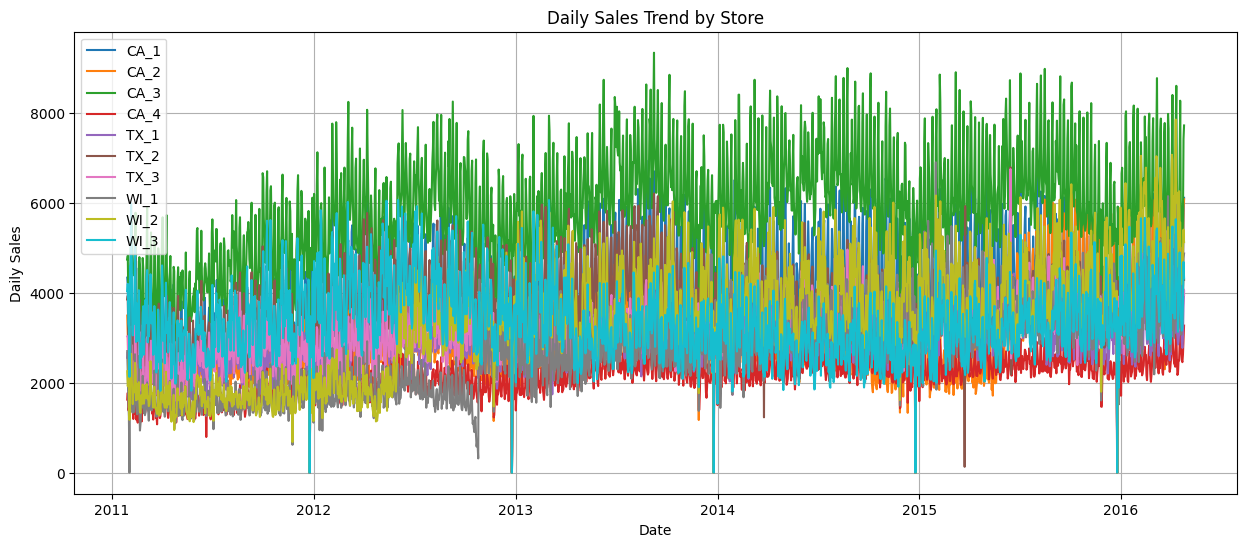

In [13]:
plt.figure(figsize=(15, 6))

for store in store_daily_df["store_id"].unique():
    temp_df = store_daily_df[store_daily_df["store_id"] == store]
    plt.plot(temp_df["date"], temp_df["sales"], label=store)

plt.title("Daily Sales Trend by Store")
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
store_summary_df = (
    store_daily_df
    .groupby(["store_id", "state_id"], as_index=False)
    .agg(
        avg_daily_sales=("sales", "mean"),
        median_daily_sales=("sales", "median"),
        min_daily_sales=("sales", "min"),
        max_daily_sales=("sales", "max"),
        total_sales=("sales", "sum")
    )
    .sort_values("total_sales", ascending=False)
)

store_summary_df

,store_id,state_id,avg_daily_sales,median_daily_sales,min_daily_sales,max_daily_sales,total_sales
2,CA_3,CA,5848.499739,5808.0,0,9338,11188180
0,CA_1,CA,4024.158913,3902.0,0,6948,7698216
5,TX_2,TX,3771.240983,3638.0,0,6793,7214384
8,WI_2,WI,3420.811291,3502.0,0,7852,6544012
9,WI_3,WI,3360.053319,3254.0,0,6065,6427782
6,TX_3,TX,3183.131208,3162.0,1,6750,6089330
1,CA_2,CA,2972.020387,2773.0,2,6542,5685475
4,TX_1,TX,2924.878202,2837.0,0,5190,5595292
7,WI_1,WI,2691.616309,2650.0,0,6902,5149062
3,CA_4,CA,2145.152117,2174.0,0,3343,4103676


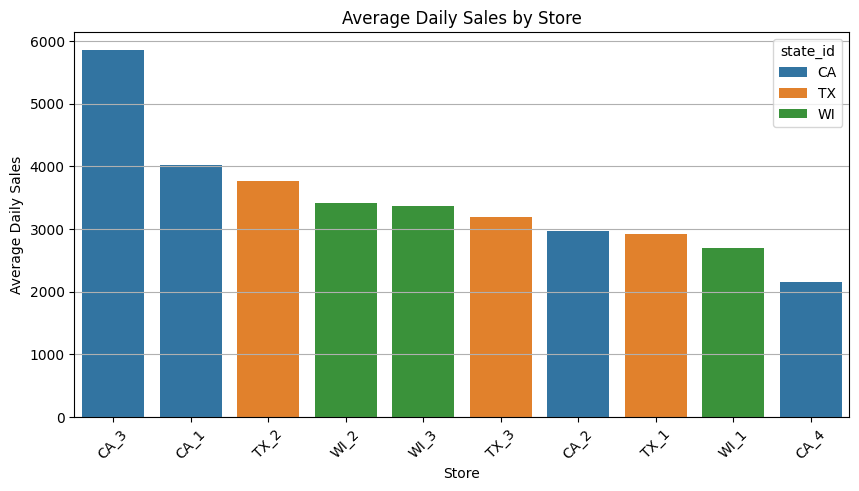

In [15]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=store_summary_df,
    x="store_id",
    y="avg_daily_sales",
    hue="state_id"
)

plt.title("Average Daily Sales by Store")
plt.xlabel("Store")
plt.ylabel("Average Daily Sales")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

In [17]:
snap_store_summary_df = (
    store_daily_df
    .groupby(["store_id", "state_id", "snap"], as_index=False)
    .agg(avg_sales=("sales", "mean"))
)

snap_store_summary_df.head()

,store_id,state_id,snap,avg_sales
0,CA_1,CA,0,3897.100546
1,CA_1,CA,1,4282.914286
2,CA_2,CA,0,2949.489478
3,CA_2,CA,1,3017.904762
4,CA_3,CA,0,5646.379579


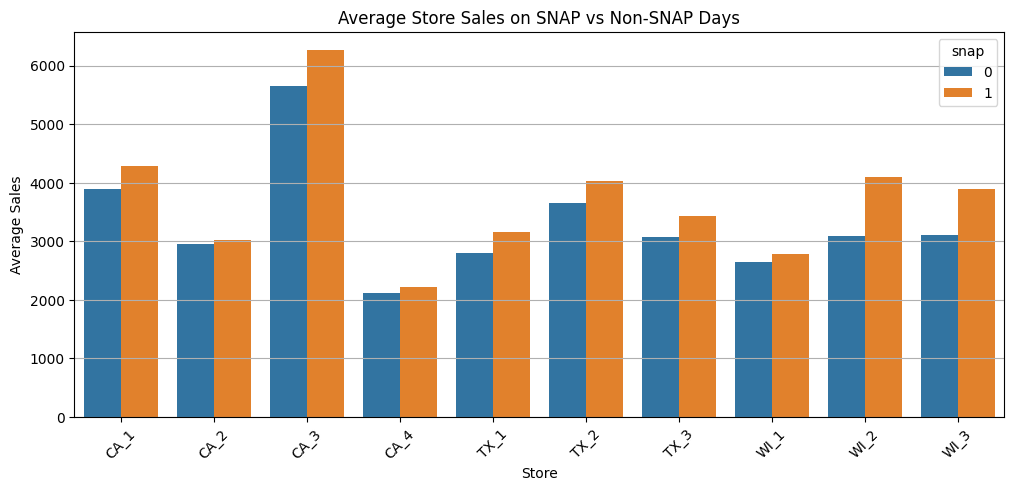

In [18]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=snap_store_summary_df,
    x="store_id",
    y="avg_sales",
    hue="snap"
)

plt.title("Average Store Sales on SNAP vs Non-SNAP Days")
plt.xlabel("Store")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

## 3. Baseline Forecasting

Before training SARIMAX models, we create simple baseline forecasts for each store.

We use:

1. Naive forecast: last observed value
2. 7-day moving average forecast: average of the last 7 days

In [19]:
FORECAST_HORIZON = 28

def evaluate_forecast(y_true, y_pred, model_name):
    """
    Evaluate forecast using MAE, RMSE, and MAPE.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    y_true_safe = np.where(y_true == 0, np.nan, y_true)
    mape = np.nanmean(np.abs((y_true - y_pred) / y_true_safe)) * 100
    
    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

In [20]:
def prepare_store_timeseries(store_daily_df, store_name):
    """
    Prepare daily time series data for one store.
    """
    store_df = store_daily_df[
        store_daily_df["store_id"] == store_name
    ].copy()
    
    store_df = store_df.sort_values("date")
    
    store_ts = store_df[["date", "sales", "snap"]].copy()
    store_ts = store_ts.set_index("date")
    store_ts = store_ts.asfreq("D")
    
    store_ts = store_ts.fillna(0)
    
    return store_ts

In [21]:
def run_store_baselines(store_daily_df, store_name, forecast_horizon=28):
    """
    Run naive and 7-day moving average baselines for one store.
    """
    store_ts = prepare_store_timeseries(
        store_daily_df=store_daily_df,
        store_name=store_name
    )
    
    train_data = store_ts.iloc[:-forecast_horizon].copy()
    test_data = store_ts.iloc[-forecast_horizon:].copy()
    
    y_train_store = train_data["sales"]
    y_test_store = test_data["sales"]
    
    last_observed_value = y_train_store.iloc[-1]
    naive_forecast = np.repeat(last_observed_value, forecast_horizon)
    
    last_7_day_avg = y_train_store.iloc[-7:].mean()
    moving_avg_forecast = np.repeat(last_7_day_avg, forecast_horizon)
    
    naive_results = evaluate_forecast(
        y_true=y_test_store.values,
        y_pred=naive_forecast,
        model_name=f"Naive Forecast - {store_name}"
    )
    
    moving_avg_results = evaluate_forecast(
        y_true=y_test_store.values,
        y_pred=moving_avg_forecast,
        model_name=f"7-Day Moving Average - {store_name}"
    )
    
    naive_results["store_id"] = store_name
    moving_avg_results["store_id"] = store_name
    
    forecast_df = pd.DataFrame({
        "date": y_test_store.index,
        "store_id": store_name,
        "actual_sales": y_test_store.values,
        "naive_forecast": naive_forecast,
        "moving_avg_forecast": moving_avg_forecast
    })
    
    return [naive_results, moving_avg_results], forecast_df

In [22]:
all_stores = store_daily_df["store_id"].unique().tolist()

all_store_baseline_metrics = []
all_store_baseline_forecasts = []

for store in all_stores:
    print("Running baselines for:", store)
    
    metrics, forecast_df = run_store_baselines(
        store_daily_df=store_daily_df,
        store_name=store,
        forecast_horizon=FORECAST_HORIZON
    )
    
    all_store_baseline_metrics.extend(metrics)
    all_store_baseline_forecasts.append(forecast_df)
    
    print("Done:", store)
    print("-" * 50)

store_baseline_results_df = pd.DataFrame(all_store_baseline_metrics)

store_baseline_results_df.sort_values(["store_id", "MAPE"])

Running baselines for: CA_1
Done: CA_1
--------------------------------------------------
Running baselines for: CA_2
Done: CA_2
--------------------------------------------------
Running baselines for: CA_3
Done: CA_3
--------------------------------------------------
Running baselines for: CA_4
Done: CA_4
--------------------------------------------------
Running baselines for: TX_1
Done: TX_1
--------------------------------------------------
Running baselines for: TX_2
Done: TX_2
--------------------------------------------------
Running baselines for: TX_3
Done: TX_3
--------------------------------------------------
Running baselines for: WI_1
Done: WI_1
--------------------------------------------------
Running baselines for: WI_2
Done: WI_2
--------------------------------------------------
Running baselines for: WI_3
Done: WI_3
--------------------------------------------------


,model,MAE,RMSE,MAPE,store_id
1,7-Day Moving Average - CA_1,825.617347,964.382416,17.788969,CA_1
0,Naive Forecast - CA_1,862.750000,966.632280,19.300595,CA_1
3,7-Day Moving Average - CA_2,925.423469,1065.060075,20.463653,CA_2
2,Naive Forecast - CA_2,1852.321429,2117.879406,48.574844,CA_2
5,7-Day Moving Average - CA_3,922.142857,1059.496006,14.603286,CA_3
4,Naive Forecast - CA_3,1509.928571,1696.615518,26.287574,CA_3
7,7-Day Moving Average - CA_4,259.882653,308.390051,9.725962,CA_4
6,Naive Forecast - CA_4,268.892857,309.730932,10.217050,CA_4
9,7-Day Moving Average - TX_1,414.316327,499.937425,12.407438,TX_1
8,Naive Forecast - TX_1,1275.571429,1370.032429,41.527950,TX_1


In [23]:
best_store_baseline_df = (
    store_baseline_results_df
    .sort_values(["store_id", "MAPE"])
    .groupby("store_id", as_index=False)
    .first()
)

best_store_baseline_df

,store_id,model,MAE,RMSE,MAPE
0,CA_1,7-Day Moving Average - CA_1,825.617347,964.382416,17.788969
1,CA_2,7-Day Moving Average - CA_2,925.423469,1065.060075,20.463653
2,CA_3,7-Day Moving Average - CA_3,922.142857,1059.496006,14.603286
3,CA_4,7-Day Moving Average - CA_4,259.882653,308.390051,9.725962
4,TX_1,7-Day Moving Average - TX_1,414.316327,499.937425,12.407438
5,TX_2,7-Day Moving Average - TX_2,561.275510,638.803393,14.931647
6,TX_3,7-Day Moving Average - TX_3,384.224490,473.351209,10.296606
7,WI_1,Naive Forecast - WI_1,751.892857,960.639835,18.092203
8,WI_2,7-Day Moving Average - WI_2,1116.428571,1406.467873,18.753412
9,WI_3,7-Day Moving Average - WI_3,687.632653,883.912643,15.862460


## 4. SNAP-only SARIMAX Tuning

Now we train and tune SARIMAX models for each store using sales history and SNAP as the external variable.

We test multiple SARIMAX configurations and select the best model per store based on MAPE.

In [24]:
store_sarimax_configs = [
    {
        "order": (1, 1, 1),
        "seasonal_order": (1, 1, 1, 7)
    },
    {
        "order": (1, 1, 0),
        "seasonal_order": (1, 1, 1, 7)
    },
    {
        "order": (0, 1, 1),
        "seasonal_order": (1, 1, 1, 7)
    },
    {
        "order": (1, 1, 1),
        "seasonal_order": (0, 1, 1, 7)
    },
    {
        "order": (1, 1, 1),
        "seasonal_order": (1, 1, 0, 7)
    },
    {
        "order": (0, 1, 1),
        "seasonal_order": (0, 1, 1, 7)
    }
]

In [25]:
def run_store_sarimax_pipeline(
    store_daily_df,
    store_name,
    forecast_horizon=28,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7)
):
    """
    Run SARIMAX forecasting pipeline for one store using SNAP as exogenous variable.
    """
    
    store_ts = prepare_store_timeseries(
        store_daily_df=store_daily_df,
        store_name=store_name
    )
    
    train_data = store_ts.iloc[:-forecast_horizon].copy()
    test_data = store_ts.iloc[-forecast_horizon:].copy()
    
    y_train_store = train_data["sales"]
    y_test_store = test_data["sales"]
    
    X_train_store = train_data[["snap"]]
    X_test_store = test_data[["snap"]]
    
    model = SARIMAX(
        y_train_store,
        exog=X_train_store,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    result = model.fit(disp=False, maxiter=100)
    
    forecast_result = result.get_forecast(
        steps=forecast_horizon,
        exog=X_test_store
    )
    
    forecast_values = forecast_result.predicted_mean
    
    metrics = evaluate_forecast(
        y_true=y_test_store.values,
        y_pred=forecast_values.values,
        model_name=f"SARIMAX {order}{seasonal_order} - {store_name}"
    )
    
    metrics["store_id"] = store_name
    metrics["AIC"] = result.aic
    metrics["order"] = order
    metrics["seasonal_order"] = seasonal_order
    metrics["converged"] = result.mle_retvals.get("converged", None)
    metrics["feature_set"] = "snap_only"
    
    forecast_df = pd.DataFrame({
        "date": y_test_store.index,
        "store_id": store_name,
        "actual_sales": y_test_store.values,
        "sarimax_forecast": forecast_values.values
    })
    
    return metrics, forecast_df, result

In [26]:
def tune_sarimax_for_store(
    store_daily_df,
    store_name,
    configs,
    forecast_horizon=28
):
    """
    Tune SARIMAX models for one store and return all results.
    """
    
    store_results = []
    store_models = {}
    store_forecasts = {}
    
    for config in configs:
        order = config["order"]
        seasonal_order = config["seasonal_order"]
        
        model_label = f"SARIMAX {order}{seasonal_order} - {store_name}"
        
        print("Training:", model_label)
        
        try:
            metrics, forecast_df, model_result = run_store_sarimax_pipeline(
                store_daily_df=store_daily_df,
                store_name=store_name,
                forecast_horizon=forecast_horizon,
                order=order,
                seasonal_order=seasonal_order
            )
            
            metrics["model_label"] = model_label
            
            store_results.append(metrics)
            store_models[model_label] = model_result
            store_forecasts[model_label] = forecast_df
            
            print("Done:", model_label)
            print("MAPE:", round(metrics["MAPE"], 2), "%")
            print("Converged:", metrics["converged"])
            print("-" * 50)
            
        except Exception as e:
            print("Failed:", model_label)
            print("Error:", e)
            print("-" * 50)
    
    store_results_df = pd.DataFrame(store_results)
    
    if store_results_df.empty:
        return store_results_df, store_models, store_forecasts
    
    store_results_df = store_results_df.sort_values("MAPE")
    
    return store_results_df, store_models, store_forecasts

In [27]:
all_store_tuned_results = []
all_store_tuned_models = {}
all_store_tuned_forecasts = {}

for store in all_stores:
    print("=" * 70)
    print("Tuning store:", store)
    print("=" * 70)
    
    store_results_df, store_models, store_forecasts = tune_sarimax_for_store(
        store_daily_df=store_daily_df,
        store_name=store,
        configs=store_sarimax_configs,
        forecast_horizon=FORECAST_HORIZON
    )
    
    if store_results_df.empty:
        print("No successful model for:", store)
        continue
    
    best_row = store_results_df.iloc[0]
    best_model_label = best_row["model_label"]
    
    all_store_tuned_results.append(best_row)
    all_store_tuned_models[store] = store_models[best_model_label]
    all_store_tuned_forecasts[store] = store_forecasts[best_model_label]
    
    print("Best model for", store)
    print("Model:", best_model_label)
    print("MAPE:", round(best_row["MAPE"], 2), "%")
    print()

Tuning store: CA_1
Training: SARIMAX (1, 1, 1)(1, 1, 1, 7) - CA_1
Done: SARIMAX (1, 1, 1)(1, 1, 1, 7) - CA_1
MAPE: 4.2 %
Converged: True
--------------------------------------------------
Training: SARIMAX (1, 1, 0)(1, 1, 1, 7) - CA_1
Done: SARIMAX (1, 1, 0)(1, 1, 1, 7) - CA_1
MAPE: 16.39 %
Converged: True
--------------------------------------------------
Training: SARIMAX (0, 1, 1)(1, 1, 1, 7) - CA_1
Done: SARIMAX (0, 1, 1)(1, 1, 1, 7) - CA_1
MAPE: 4.24 %
Converged: True
--------------------------------------------------
Training: SARIMAX (1, 1, 1)(0, 1, 1, 7) - CA_1
Done: SARIMAX (1, 1, 1)(0, 1, 1, 7) - CA_1
MAPE: 4.34 %
Converged: True
--------------------------------------------------
Training: SARIMAX (1, 1, 1)(1, 1, 0, 7) - CA_1
Done: SARIMAX (1, 1, 1)(1, 1, 0, 7) - CA_1
MAPE: 7.1 %
Converged: True
--------------------------------------------------
Training: SARIMAX (0, 1, 1)(0, 1, 1, 7) - CA_1
Done: SARIMAX (0, 1, 1)(0, 1, 1, 7) - CA_1
MAPE: 4.47 %
Converged: True
-------------

In [28]:
all_store_tuned_results_df = pd.DataFrame(all_store_tuned_results)

all_store_tuned_results_df = all_store_tuned_results_df[
    [
        "store_id",
        "model",
        "feature_set",
        "order",
        "seasonal_order",
        "MAE",
        "RMSE",
        "MAPE",
        "AIC",
        "converged"
    ]
].sort_values("MAPE")

all_store_tuned_results_df

,store_id,model,feature_set,order,seasonal_order,MAE,RMSE,MAPE,AIC,converged
0,CA_1,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - CA_1",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",195.009094,254.671961,4.203054,27798.402435,True
5,CA_4,"SARIMAX (0, 1, 1)(0, 1, 1, 7) - CA_4",snap_only,"(0, 1, 1)","(0, 1, 1, 7)",115.396552,142.074421,4.503819,25217.651775,True
0,TX_3,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - TX_3",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",187.229438,256.127864,5.267616,26931.578135,True
0,TX_1,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - TX_1",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",165.282334,200.524789,5.331611,26553.116616,True
3,WI_3,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - WI_3",snap_only,"(1, 1, 1)","(0, 1, 1, 7)",208.704867,267.357287,5.351773,27806.349738,True
0,CA_3,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - CA_3",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",339.246382,400.842316,5.692324,28797.225359,True
0,CA_2,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - CA_2",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",290.447446,363.266541,6.011862,27059.797839,True
0,WI_1,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - WI_1",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",245.691978,326.042276,6.092563,27461.661258,True
1,TX_2,"SARIMAX (1, 1, 0)(1, 1, 1, 7) - TX_2",snap_only,"(1, 1, 0)","(1, 1, 1, 7)",320.816115,381.854077,8.867170,28316.076512,True
3,WI_2,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - WI_2",snap_only,"(1, 1, 1)","(0, 1, 1, 7)",529.234518,662.610576,9.439917,28225.168483,True


## 5. Calendar-Feature SARIMAX Experiment

The SNAP-only SARIMAX models performed strongly at store level.

Now we test whether additional calendar features improve performance:

- SNAP indicator
- weekday dummy variables
- month dummy variables
- event indicator

We compare this against the SNAP-only models and select the final stable model per store.

In [29]:
store_daily_enriched_df = (
    sales_long_df
    .groupby(["date", "store_id", "state_id"], as_index=False)
    .agg(
        sales=("sales", "sum"),
        snap=("snap", "max"),
        weekday=("weekday", "first"),
        month=("month", "first"),
        event_name_1=("event_name_1", "first"),
        event_type_1=("event_type_1", "first")
    )
)

store_daily_enriched_df["is_event"] = (
    store_daily_enriched_df["event_name_1"]
    .notna()
    .astype(int)
)

print("Enriched store daily shape:", store_daily_enriched_df.shape)

store_daily_enriched_df.head()

Enriched store daily shape: (19130, 10)


,date,store_id,state_id,sales,snap,weekday,month,event_name_1,event_type_1,is_event
0,2011-01-29,CA_1,CA,4337,0,Saturday,1,NaN,NaN,0
1,2011-01-29,CA_2,CA,3494,0,Saturday,1,NaN,NaN,0
2,2011-01-29,CA_3,CA,4739,0,Saturday,1,NaN,NaN,0
3,2011-01-29,CA_4,CA,1625,0,Saturday,1,NaN,NaN,0
4,2011-01-29,TX_1,TX,2556,0,Saturday,1,NaN,NaN,0


In [30]:
def prepare_store_timeseries_with_features(store_daily_enriched_df, store_name):
    """
    Prepare daily store time series with numeric calendar exogenous features.
    """
    store_df = store_daily_enriched_df[
        store_daily_enriched_df["store_id"] == store_name
    ].copy()
    
    store_df = store_df.sort_values("date")
    
    store_ts = store_df[
        ["date", "sales", "snap", "weekday", "month", "is_event"]
    ].copy()
    
    store_ts = store_ts.set_index("date")
    store_ts = store_ts.asfreq("D")
    
    weekday_dummies = pd.get_dummies(
        store_ts["weekday"],
        prefix="weekday",
        drop_first=True,
        dtype=int
    )
    
    month_dummies = pd.get_dummies(
        store_ts["month"].astype(str),
        prefix="month",
        drop_first=True,
        dtype=int
    )
    
    store_ts = pd.concat(
        [
            store_ts[["sales", "snap", "is_event"]],
            weekday_dummies,
            month_dummies
        ],
        axis=1
    )
    
    store_ts = store_ts.fillna(0)
    store_ts = store_ts.apply(pd.to_numeric, errors="coerce").fillna(0)
    store_ts = store_ts.astype(float)
    
    return store_ts

In [31]:
test_store_ts = prepare_store_timeseries_with_features(
    store_daily_enriched_df=store_daily_enriched_df,
    store_name="CA_1"
)

print(test_store_ts.shape)
print(test_store_ts.dtypes)

test_store_ts.head()

(1913, 20)
sales                float64
snap                 float64
is_event             float64
weekday_Monday       float64
weekday_Saturday     float64
weekday_Sunday       float64
weekday_Thursday     float64
weekday_Tuesday      float64
weekday_Wednesday    float64
month_10             float64
month_11             float64
month_12             float64
month_2              float64
month_3              float64
month_4              float64
month_5              float64
month_6              float64
month_7              float64
month_8              float64
month_9              float64
dtype: object


,sales,snap,is_event,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,month_10,month_11,month_12,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9
date,,,,,,,,,,,,,,,,,,,,
2011-01-29,4337.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-30,4155.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-31,2816.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-02-01,3051.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-02-02,2630.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
def run_store_sarimax_with_calendar_features(
    store_daily_enriched_df,
    store_name,
    forecast_horizon=28,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7)
):
    """
    Run SARIMAX with SNAP + weekday + month + event features for one store.
    """
    
    store_ts = prepare_store_timeseries_with_features(
        store_daily_enriched_df=store_daily_enriched_df,
        store_name=store_name
    )
    
    train_data = store_ts.iloc[:-forecast_horizon].copy()
    test_data = store_ts.iloc[-forecast_horizon:].copy()
    
    y_train_store = train_data["sales"]
    y_test_store = test_data["sales"]
    
    X_train_store = train_data.drop(columns=["sales"])
    X_test_store = test_data.drop(columns=["sales"])
    
    model = SARIMAX(
        y_train_store,
        exog=X_train_store,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    result = model.fit(disp=False, maxiter=100)
    
    forecast_result = result.get_forecast(
        steps=forecast_horizon,
        exog=X_test_store
    )
    
    forecast_values = forecast_result.predicted_mean
    
    metrics = evaluate_forecast(
        y_true=y_test_store.values,
        y_pred=forecast_values.values,
        model_name=f"Calendar SARIMAX {order}{seasonal_order} - {store_name}"
    )
    
    metrics["store_id"] = store_name
    metrics["AIC"] = result.aic
    metrics["order"] = order
    metrics["seasonal_order"] = seasonal_order
    metrics["converged"] = result.mle_retvals.get("converged", None)
    metrics["feature_set"] = "snap_weekday_month_event"
    
    forecast_df = pd.DataFrame({
        "date": y_test_store.index,
        "store_id": store_name,
        "actual_sales": y_test_store.values,
        "calendar_sarimax_forecast": forecast_values.values
    })
    
    return metrics, forecast_df, result

In [33]:
def tune_calendar_sarimax_for_store(
    store_daily_enriched_df,
    store_name,
    configs,
    forecast_horizon=28
):
    """
    Tune calendar-feature SARIMAX models for one store.
    """
    
    store_results = []
    store_models = {}
    store_forecasts = {}
    
    for config in configs:
        order = config["order"]
        seasonal_order = config["seasonal_order"]
        
        model_label = f"Calendar SARIMAX {order}{seasonal_order} - {store_name}"
        
        print("Training:", model_label)
        
        try:
            metrics, forecast_df, model_result = run_store_sarimax_with_calendar_features(
                store_daily_enriched_df=store_daily_enriched_df,
                store_name=store_name,
                forecast_horizon=forecast_horizon,
                order=order,
                seasonal_order=seasonal_order
            )
            
            metrics["model_label"] = model_label
            
            store_results.append(metrics)
            store_models[model_label] = model_result
            store_forecasts[model_label] = forecast_df
            
            print("Done:", model_label)
            print("MAPE:", round(metrics["MAPE"], 2), "%")
            print("Converged:", metrics["converged"])
            print("-" * 50)
            
        except Exception as e:
            print("Failed:", model_label)
            print("Error:", e)
            print("-" * 50)
    
    store_results_df = pd.DataFrame(store_results)
    
    if store_results_df.empty:
        return store_results_df, store_models, store_forecasts
    
    store_results_df = store_results_df.sort_values("MAPE")
    
    return store_results_df, store_models, store_forecasts

In [34]:
all_store_calendar_results = []
all_store_calendar_models = {}
all_store_calendar_forecasts = {}

for store in all_stores:
    print("=" * 70)
    print("Calendar feature tuning for store:", store)
    print("=" * 70)
    
    store_results_df, store_models, store_forecasts = tune_calendar_sarimax_for_store(
        store_daily_enriched_df=store_daily_enriched_df,
        store_name=store,
        configs=store_sarimax_configs,
        forecast_horizon=FORECAST_HORIZON
    )
    
    if store_results_df.empty:
        print("No successful calendar model for:", store)
        continue
    
    best_row = store_results_df.iloc[0]
    best_model_label = best_row["model_label"]
    
    all_store_calendar_results.append(best_row)
    all_store_calendar_models[store] = store_models[best_model_label]
    all_store_calendar_forecasts[store] = store_forecasts[best_model_label]
    
    print("Best calendar model for", store)
    print("Model:", best_model_label)
    print("MAPE:", round(best_row["MAPE"], 2), "%")
    print()

Calendar feature tuning for store: CA_1
Training: Calendar SARIMAX (1, 1, 1)(1, 1, 1, 7) - CA_1
Done: Calendar SARIMAX (1, 1, 1)(1, 1, 1, 7) - CA_1
MAPE: 5.23 %
Converged: True
--------------------------------------------------
Training: Calendar SARIMAX (1, 1, 0)(1, 1, 1, 7) - CA_1
Done: Calendar SARIMAX (1, 1, 0)(1, 1, 1, 7) - CA_1
MAPE: 8.87 %
Converged: True
--------------------------------------------------
Training: Calendar SARIMAX (0, 1, 1)(1, 1, 1, 7) - CA_1
Done: Calendar SARIMAX (0, 1, 1)(1, 1, 1, 7) - CA_1
MAPE: 6.82 %
Converged: True
--------------------------------------------------
Training: Calendar SARIMAX (1, 1, 1)(0, 1, 1, 7) - CA_1
Done: Calendar SARIMAX (1, 1, 1)(0, 1, 1, 7) - CA_1
MAPE: 5.63 %
Converged: True
--------------------------------------------------
Training: Calendar SARIMAX (1, 1, 1)(1, 1, 0, 7) - CA_1
Done: Calendar SARIMAX (1, 1, 1)(1, 1, 0, 7) - CA_1
MAPE: 8.47 %
Converged: True
--------------------------------------------------
Training: Calendar S

In [35]:
all_store_calendar_results_df = pd.DataFrame(all_store_calendar_results)

all_store_calendar_results_df = all_store_calendar_results_df[
    [
        "store_id",
        "model",
        "feature_set",
        "order",
        "seasonal_order",
        "MAE",
        "RMSE",
        "MAPE",
        "AIC",
        "converged"
    ]
].sort_values("MAPE")

all_store_calendar_results_df

,store_id,model,feature_set,order,seasonal_order,MAE,RMSE,MAPE,AIC,converged
2,CA_2,"Calendar SARIMAX (0, 1, 1)(1, 1, 1, 7) - CA_2",snap_weekday_month_event,"(0, 1, 1)","(1, 1, 1, 7)",216.386811,286.086171,4.690289,27280.643298,True
1,TX_3,"Calendar SARIMAX (1, 1, 0)(1, 1, 1, 7) - TX_3",snap_weekday_month_event,"(1, 1, 0)","(1, 1, 1, 7)",188.956578,252.758196,5.200548,27443.049970,True
0,CA_1,"Calendar SARIMAX (1, 1, 1)(1, 1, 1, 7) - CA_1",snap_weekday_month_event,"(1, 1, 1)","(1, 1, 1, 7)",220.205264,262.670337,5.231058,27840.914891,True
0,TX_1,"Calendar SARIMAX (1, 1, 1)(1, 1, 1, 7) - TX_1",snap_weekday_month_event,"(1, 1, 1)","(1, 1, 1, 7)",162.944830,212.444620,5.307342,26664.205647,True
3,CA_4,"Calendar SARIMAX (1, 1, 1)(0, 1, 1, 7) - CA_4",snap_weekday_month_event,"(1, 1, 1)","(0, 1, 1, 7)",147.957755,170.456025,5.577867,25257.586541,True
4,WI_3,"Calendar SARIMAX (1, 1, 1)(1, 1, 0, 7) - WI_3",snap_weekday_month_event,"(1, 1, 1)","(1, 1, 0, 7)",254.857175,316.916925,6.416856,28257.456209,True
1,WI_1,"Calendar SARIMAX (1, 1, 0)(1, 1, 1, 7) - WI_1",snap_weekday_month_event,"(1, 1, 0)","(1, 1, 1, 7)",308.585140,387.095306,7.678328,27986.899401,True
2,TX_2,"Calendar SARIMAX (0, 1, 1)(1, 1, 1, 7) - TX_2",snap_weekday_month_event,"(0, 1, 1)","(1, 1, 1, 7)",343.359546,392.878870,8.902356,27868.126120,True
3,WI_2,"Calendar SARIMAX (1, 1, 1)(0, 1, 1, 7) - WI_2",snap_weekday_month_event,"(1, 1, 1)","(0, 1, 1, 7)",573.776724,745.118198,9.829094,28200.562270,True
4,CA_3,"Calendar SARIMAX (1, 1, 1)(1, 1, 0, 7) - CA_3",snap_weekday_month_event,"(1, 1, 1)","(1, 1, 0, 7)",668.369439,769.726776,10.972035,29578.855345,True


## 6. Feature Experiment Comparison

We compare two store-level SARIMAX setups:

1. SNAP-only SARIMAX
2. Calendar-feature SARIMAX using SNAP, weekday, month, and event indicators

Unlike category and department level, calendar features improved some stores but not all.

For final model selection, we choose the lowest MAPE model per store among stable converged models.

In [36]:
snap_only_store_results_df = all_store_tuned_results_df.copy()
calendar_store_results_df = all_store_calendar_results_df.copy()

store_feature_comparison_df = pd.concat(
    [
        snap_only_store_results_df[
            [
                "store_id",
                "model",
                "feature_set",
                "order",
                "seasonal_order",
                "MAE",
                "RMSE",
                "MAPE",
                "AIC",
                "converged"
            ]
        ],
        calendar_store_results_df[
            [
                "store_id",
                "model",
                "feature_set",
                "order",
                "seasonal_order",
                "MAE",
                "RMSE",
                "MAPE",
                "AIC",
                "converged"
            ]
        ]
    ],
    ignore_index=True
)

store_feature_comparison_df = store_feature_comparison_df.sort_values(
    ["store_id", "MAPE"]
)

store_feature_comparison_df

,store_id,model,feature_set,order,seasonal_order,MAE,RMSE,MAPE,AIC,converged
0,CA_1,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - CA_1",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",195.009094,254.671961,4.203054,27798.402435,True
12,CA_1,"Calendar SARIMAX (1, 1, 1)(1, 1, 1, 7) - CA_1",snap_weekday_month_event,"(1, 1, 1)","(1, 1, 1, 7)",220.205264,262.670337,5.231058,27840.914891,True
10,CA_2,"Calendar SARIMAX (0, 1, 1)(1, 1, 1, 7) - CA_2",snap_weekday_month_event,"(0, 1, 1)","(1, 1, 1, 7)",216.386811,286.086171,4.690289,27280.643298,True
6,CA_2,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - CA_2",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",290.447446,363.266541,6.011862,27059.797839,True
5,CA_3,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - CA_3",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",339.246382,400.842316,5.692324,28797.225359,True
19,CA_3,"Calendar SARIMAX (1, 1, 1)(1, 1, 0, 7) - CA_3",snap_weekday_month_event,"(1, 1, 1)","(1, 1, 0, 7)",668.369439,769.726776,10.972035,29578.855345,True
1,CA_4,"SARIMAX (0, 1, 1)(0, 1, 1, 7) - CA_4",snap_only,"(0, 1, 1)","(0, 1, 1, 7)",115.396552,142.074421,4.503819,25217.651775,True
14,CA_4,"Calendar SARIMAX (1, 1, 1)(0, 1, 1, 7) - CA_4",snap_weekday_month_event,"(1, 1, 1)","(0, 1, 1, 7)",147.957755,170.456025,5.577867,25257.586541,True
13,TX_1,"Calendar SARIMAX (1, 1, 1)(1, 1, 1, 7) - TX_1",snap_weekday_month_event,"(1, 1, 1)","(1, 1, 1, 7)",162.944830,212.444620,5.307342,26664.205647,True
3,TX_1,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - TX_1",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",165.282334,200.524789,5.331611,26553.116616,True


In [37]:
final_store_selected_models_df = (
    store_feature_comparison_df
    .sort_values(["store_id", "converged", "MAPE"], ascending=[True, False, True])
    .groupby("store_id", as_index=False)
    .first()
)

final_store_selected_models_df

,store_id,model,feature_set,order,seasonal_order,MAE,RMSE,MAPE,AIC,converged
0,CA_1,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - CA_1",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",195.009094,254.671961,4.203054,27798.402435,True
1,CA_2,"Calendar SARIMAX (0, 1, 1)(1, 1, 1, 7) - CA_2",snap_weekday_month_event,"(0, 1, 1)","(1, 1, 1, 7)",216.386811,286.086171,4.690289,27280.643298,True
2,CA_3,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - CA_3",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",339.246382,400.842316,5.692324,28797.225359,True
3,CA_4,"SARIMAX (0, 1, 1)(0, 1, 1, 7) - CA_4",snap_only,"(0, 1, 1)","(0, 1, 1, 7)",115.396552,142.074421,4.503819,25217.651775,True
4,TX_1,"Calendar SARIMAX (1, 1, 1)(1, 1, 1, 7) - TX_1",snap_weekday_month_event,"(1, 1, 1)","(1, 1, 1, 7)",162.944830,212.444620,5.307342,26664.205647,True
5,TX_2,"SARIMAX (1, 1, 0)(1, 1, 1, 7) - TX_2",snap_only,"(1, 1, 0)","(1, 1, 1, 7)",320.816115,381.854077,8.867170,28316.076512,True
6,TX_3,"Calendar SARIMAX (1, 1, 0)(1, 1, 1, 7) - TX_3",snap_weekday_month_event,"(1, 1, 0)","(1, 1, 1, 7)",188.956578,252.758196,5.200548,27443.049970,True
7,WI_1,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - WI_1",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",245.691978,326.042276,6.092563,27461.661258,True
8,WI_2,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - WI_2",snap_only,"(1, 1, 1)","(0, 1, 1, 7)",529.234518,662.610576,9.439917,28225.168483,True
9,WI_3,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - WI_3",snap_only,"(1, 1, 1)","(0, 1, 1, 7)",208.704867,267.357287,5.351773,27806.349738,True


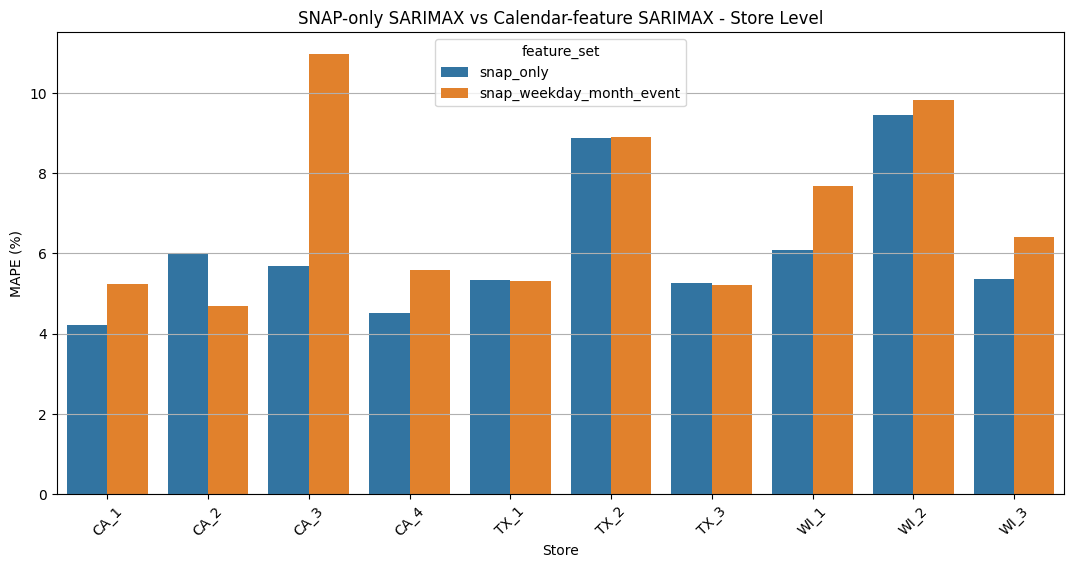

In [38]:
plt.figure(figsize=(13, 6))

sns.barplot(
    data=store_feature_comparison_df,
    x="store_id",
    y="MAPE",
    hue="feature_set"
)

plt.title("SNAP-only SARIMAX vs Calendar-feature SARIMAX - Store Level")
plt.xlabel("Store")
plt.ylabel("MAPE (%)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

In [39]:
store_feature_comparison_path = os.path.join(
    OUTPUTS_DIR,
    "store_feature_comparison_sarimax.csv"
)

final_store_selected_models_path = os.path.join(
    OUTPUTS_DIR,
    "final_store_selected_models.csv"
)

store_feature_comparison_df.to_csv(
    store_feature_comparison_path,
    index=False
)

final_store_selected_models_df.to_csv(
    final_store_selected_models_path,
    index=False
)

print("Store feature comparison saved to:")
print(store_feature_comparison_path)

print("\nFinal selected store models saved to:")
print(final_store_selected_models_path)

Store feature comparison saved to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\store_feature_comparison_sarimax.csv

Final selected store models saved to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_store_selected_models.csv


In [40]:
final_store_forecast_list = []

for _, row in final_store_selected_models_df.iterrows():
    store = row["store_id"]
    feature_set = row["feature_set"]
    
    if feature_set == "snap_only":
        forecast_df = all_store_tuned_forecasts[store].copy()
        forecast_df = forecast_df.rename(
            columns={"sarimax_forecast": "final_forecast"}
        )
    else:
        forecast_df = all_store_calendar_forecasts[store].copy()
        forecast_df = forecast_df.rename(
            columns={"calendar_sarimax_forecast": "final_forecast"}
        )
    
    forecast_df["feature_set"] = feature_set
    forecast_df["selected_model"] = row["model"]
    
    final_store_forecast_list.append(forecast_df)

final_store_forecasts_df = pd.concat(
    final_store_forecast_list,
    ignore_index=True
)

final_store_forecasts_df["error"] = (
    final_store_forecasts_df["actual_sales"]
    - final_store_forecasts_df["final_forecast"]
)

final_store_forecasts_df["absolute_error"] = (
    final_store_forecasts_df["error"].abs()
)

final_store_forecasts_df["absolute_percentage_error"] = (
    final_store_forecasts_df["absolute_error"]
    / final_store_forecasts_df["actual_sales"].replace(0, np.nan)
) * 100

print("Final store forecast shape:", final_store_forecasts_df.shape)

final_store_forecasts_df.head()

Final store forecast shape: (280, 9)


,date,store_id,actual_sales,final_forecast,feature_set,selected_model,error,absolute_error,absolute_percentage_error
0,2016-03-28,CA_1,3905.0,4009.963303,snap_only,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - CA_1",-104.963303,104.963303,2.687921
1,2016-03-29,CA_1,3788.0,3688.684098,snap_only,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - CA_1",99.315902,99.315902,2.621856
2,2016-03-30,CA_1,3339.0,3672.906312,snap_only,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - CA_1",-333.906312,333.906312,10.000189
3,2016-03-31,CA_1,4076.0,3679.123052,snap_only,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - CA_1",396.876948,396.876948,9.736922
4,2016-04-01,CA_1,4983.0,4609.639694,snap_only,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - CA_1",373.360306,373.360306,7.492681


In [41]:
store_forecast_summary_df = (
    final_store_forecasts_df
    .groupby("store_id", as_index=False)
    .agg(
        forecast_days=("date", "count"),
        avg_actual_sales=("actual_sales", "mean"),
        avg_forecast_sales=("final_forecast", "mean"),
        avg_absolute_error=("absolute_error", "mean"),
        avg_percentage_error=("absolute_percentage_error", "mean")
    )
    .sort_values("avg_percentage_error")
)

store_forecast_summary_df

,store_id,forecast_days,avg_actual_sales,avg_forecast_sales,avg_absolute_error,avg_percentage_error
0,CA_1,28,4569.821429,4479.453203,195.009094,4.203054
3,CA_4,28,2650.464286,2656.256971,115.396552,4.503819
1,CA_2,28,4465.392857,4435.566236,216.386811,4.690289
6,TX_3,28,3800.785714,3792.053503,188.956578,5.200548
4,TX_1,28,3313.428571,3380.756376,162.944830,5.307342
9,WI_3,28,3993.214286,3960.455344,208.704867,5.351773
2,CA_3,28,6320.428571,6577.882646,339.246382,5.692324
7,WI_1,28,3831.464286,3825.196181,245.691978,6.092563
5,TX_2,28,3932.357143,4226.696816,320.816115,8.867170
8,WI_2,28,5395.000000,5116.456360,529.234518,9.439917


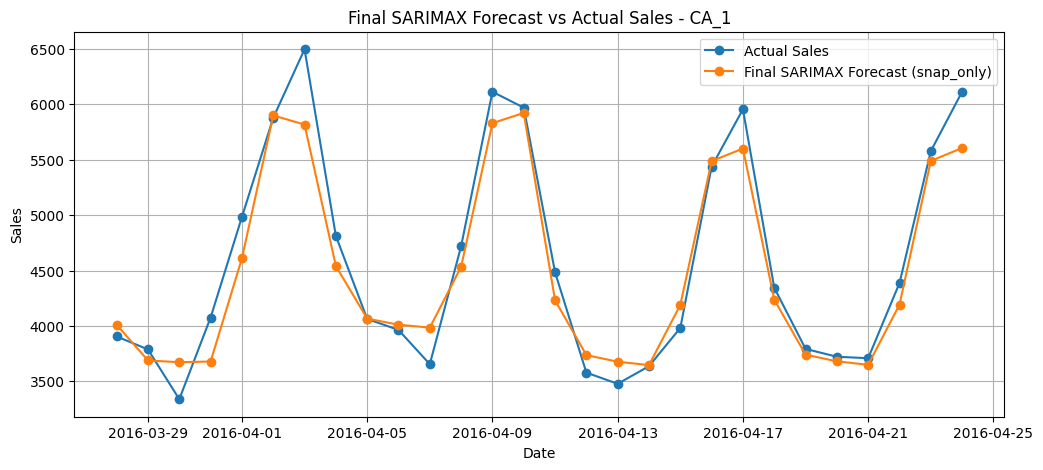

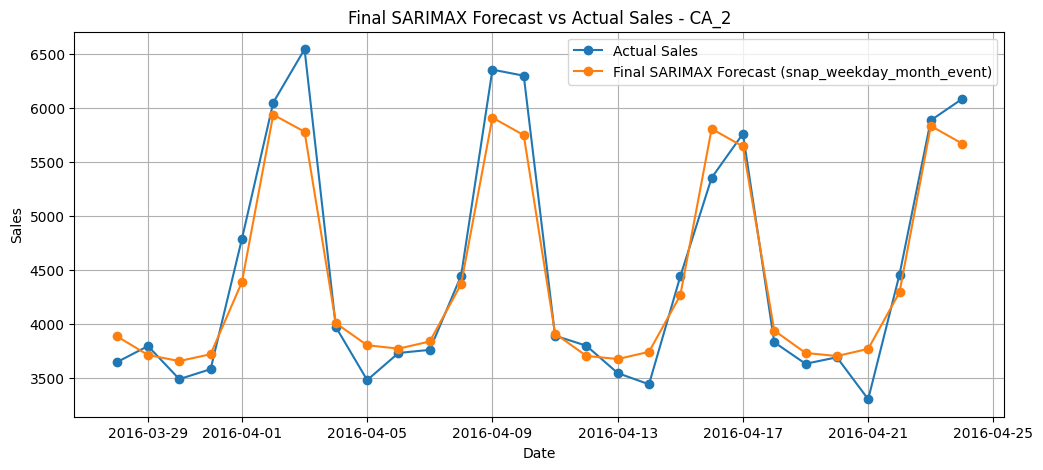

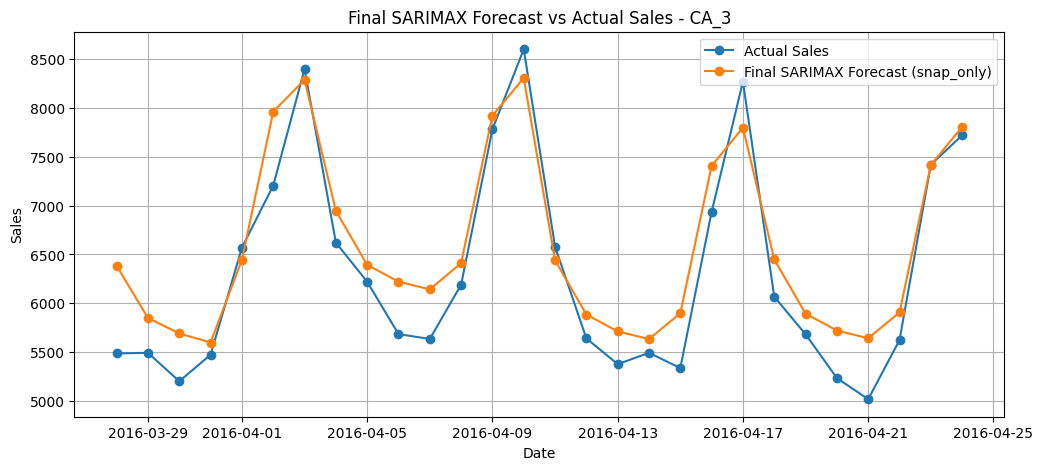

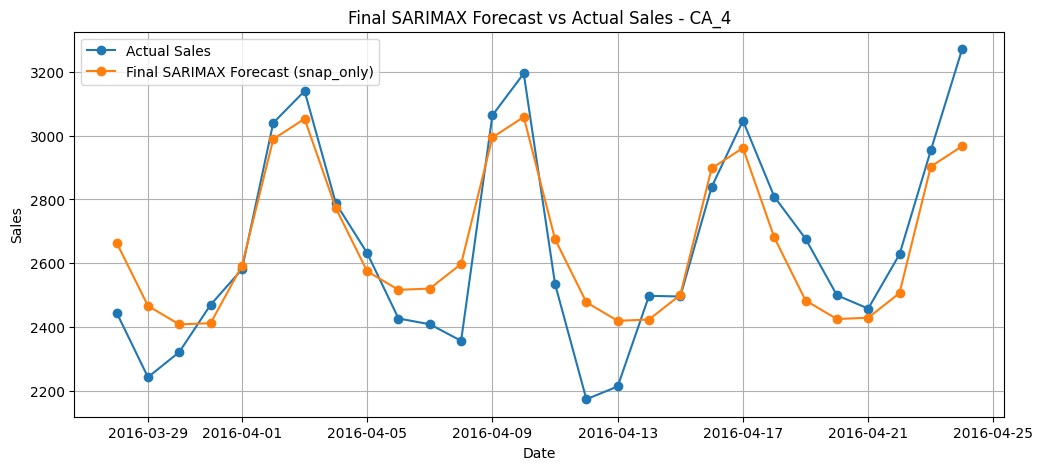

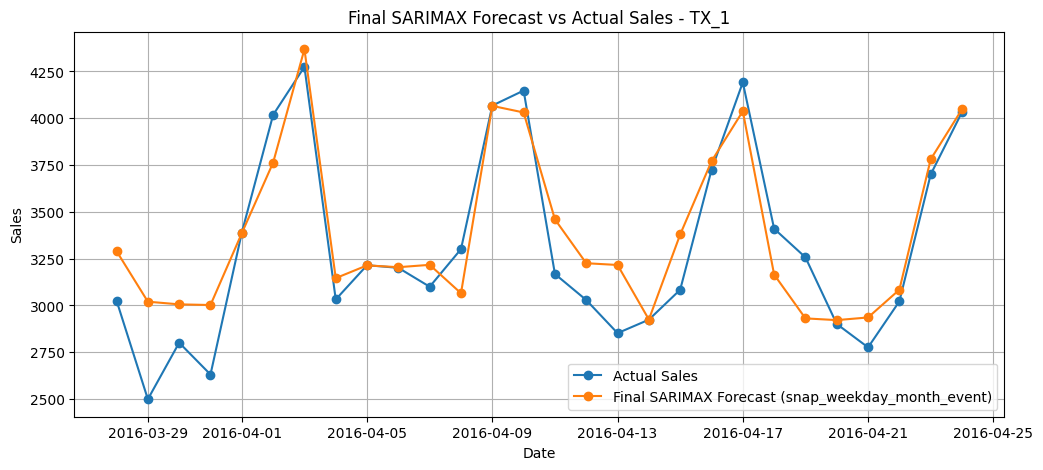

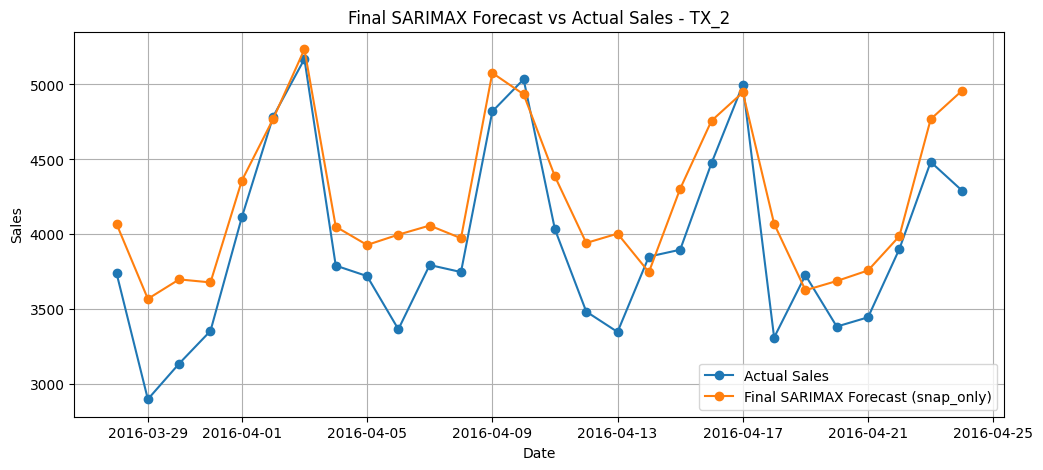

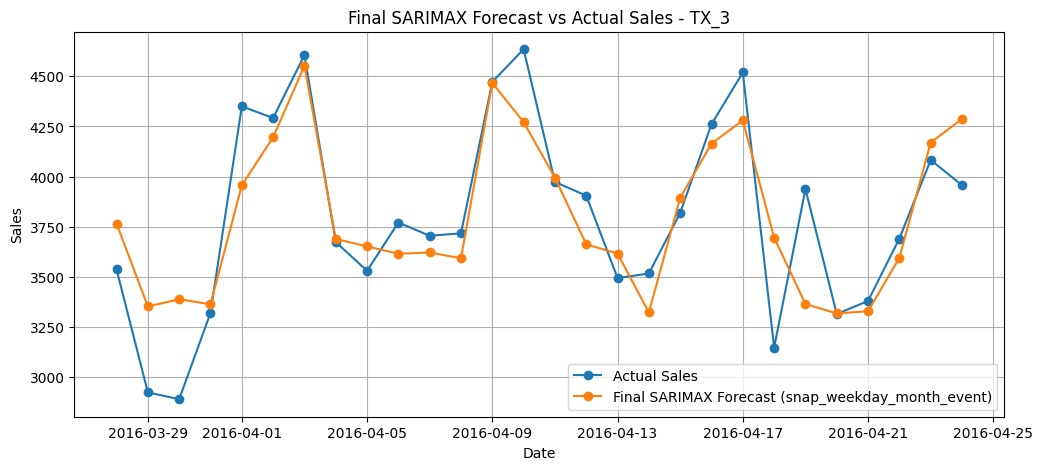

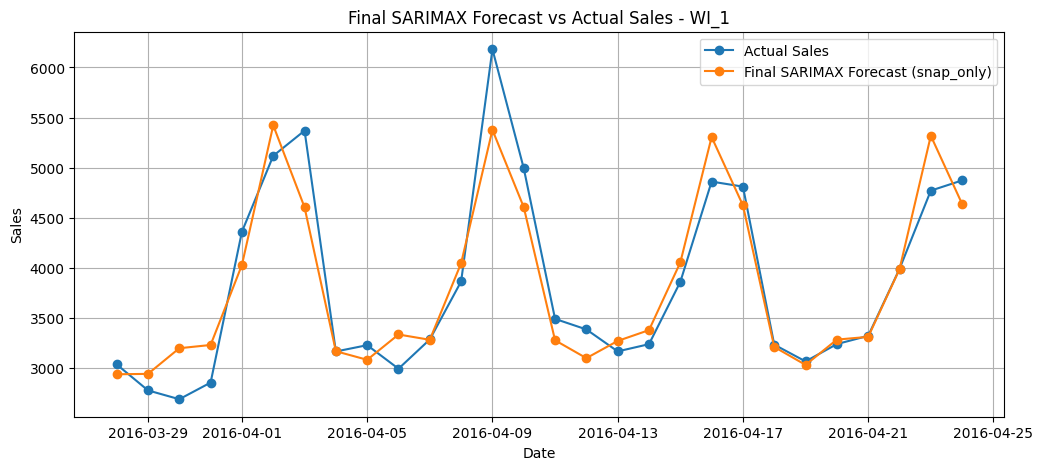

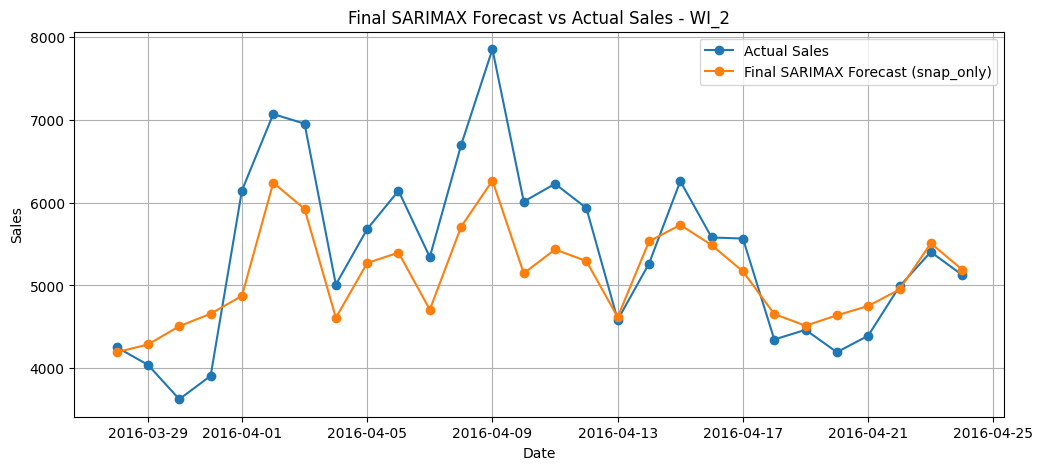

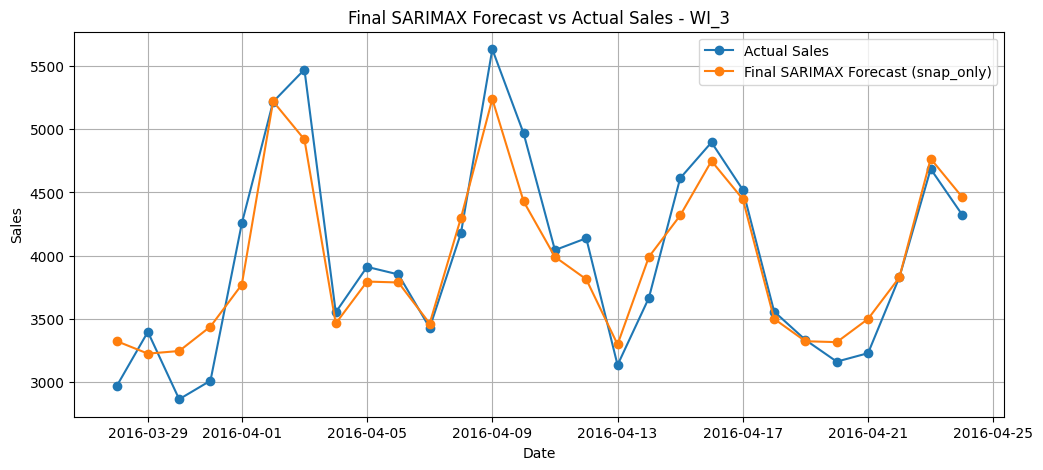

In [42]:
for store in final_store_forecasts_df["store_id"].unique():
    temp_df = final_store_forecasts_df[
        final_store_forecasts_df["store_id"] == store
    ]
    
    selected_feature_set = temp_df["feature_set"].iloc[0]
    
    plt.figure(figsize=(12, 5))
    
    plt.plot(
        temp_df["date"],
        temp_df["actual_sales"],
        label="Actual Sales",
        marker="o"
    )
    
    plt.plot(
        temp_df["date"],
        temp_df["final_forecast"],
        label=f"Final SARIMAX Forecast ({selected_feature_set})",
        marker="o"
    )
    
    plt.title(f"Final SARIMAX Forecast vs Actual Sales - {store}")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid(True)
    plt.show()

In [43]:
final_store_forecasts_path = os.path.join(
    OUTPUTS_DIR,
    "final_store_sarimax_forecasts.csv"
)

store_forecast_summary_path = os.path.join(
    OUTPUTS_DIR,
    "final_store_forecast_summary.csv"
)

final_store_forecasts_df.to_csv(
    final_store_forecasts_path,
    index=False
)

store_forecast_summary_df.to_csv(
    store_forecast_summary_path,
    index=False
)

print("Final store forecasts saved to:")
print(final_store_forecasts_path)

print("\nStore forecast summary saved to:")
print(store_forecast_summary_path)

Final store forecasts saved to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_store_sarimax_forecasts.csv

Store forecast summary saved to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_store_forecast_summary.csv


In [44]:
for _, row in final_store_selected_models_df.iterrows():
    store = row["store_id"]
    feature_set = row["feature_set"]
    
    if feature_set == "snap_only":
        model_result = all_store_tuned_models[store]
    else:
        model_result = all_store_calendar_models[store]
    
    model_path = os.path.join(
        MODELS_DIR,
        f"best_sarimax_store_{store.lower()}.pkl"
    )
    
    joblib.dump(model_result, model_path)
    
    print(f"Saved final model for {store}:")
    print(model_path)

Saved final model for CA_1:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\models\best_sarimax_store_ca_1.pkl
Saved final model for CA_2:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\models\best_sarimax_store_ca_2.pkl
Saved final model for CA_3:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\models\best_sarimax_store_ca_3.pkl
Saved final model for CA_4:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\models\best_sarimax_store_ca_4.pkl
Saved final model for TX_1:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\models\best_sarimax_store_tx_1.pkl
Saved final model for TX_2:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\models\best_sarimax_store_tx_2.pkl
Saved final model for TX_3:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\models\best_sarimax_store_tx_3.pkl
Saved final model for WI_1:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\models\best_sarimax_store_wi_1.pkl
Saved final mode

In [45]:
final_store_notebook_summary = {
    "forecast_level": "store",
    "forecast_horizon_days": FORECAST_HORIZON,
    "number_of_stores": len(all_stores),
    "best_store": store_forecast_summary_df.iloc[0]["store_id"],
    "best_store_mape": store_forecast_summary_df.iloc[0]["avg_percentage_error"],
    "weakest_store": store_forecast_summary_df.iloc[-1]["store_id"],
    "weakest_store_mape": store_forecast_summary_df.iloc[-1]["avg_percentage_error"],
    "average_mape_across_stores": store_forecast_summary_df["avg_percentage_error"].mean()
}

final_store_notebook_summary_df = pd.DataFrame([final_store_notebook_summary])

final_store_summary_path = os.path.join(
    OUTPUTS_DIR,
    "final_store_forecasting_summary.csv"
)

final_store_notebook_summary_df.to_csv(
    final_store_summary_path,
    index=False
)

print("Final store forecasting summary saved to:")
print(final_store_summary_path)

final_store_notebook_summary_df

Final store forecasting summary saved to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_store_forecasting_summary.csv


,forecast_level,forecast_horizon_days,number_of_stores,best_store,best_store_mape,weakest_store,weakest_store_mape,average_mape_across_stores
0,store,28,10,CA_1,4.203054,WI_2,9.439917,5.93488


## 7. Final Conclusion

This notebook built a store-level demand forecasting pipeline using the M5 Walmart dataset.

The raw item-level sales data was converted from wide format into long format, aggregated into store-level daily demand, and modeled using SARIMAX for 28-day forecasting.

Compared to category and department forecasting, store-level forecasting produced more stable results because demand is aggregated across all products within each store.

### Final Store-Level Insights

- CA_1 achieved the strongest forecast performance with a MAPE of around 4.20%.
- Most stores achieved MAPE below 6%, showing strong short-term forecasting performance.
- TX_2 and WI_2 had relatively higher errors, indicating more volatile demand behavior.
- Calendar features helped some stores such as CA_2, TX_1, and TX_3.
- For other stores, SNAP-only SARIMAX remained better and simpler.

### Business Takeaways

1. Store-level forecasting gives a strong high-level view of total demand across locations.
2. CA_3 has the highest average daily sales and should be treated as a high-priority store for inventory planning.
3. SNAP days generally increase average sales across stores.
4. Calendar features should not be blindly added; they should be validated store by store.
5. Final model selection should be based on validation performance, not feature complexity.

In [46]:
print("Store-level notebook completed successfully.")
print()
print("Saved files:")
print("1.", store_processed_path)
print("2.", store_feature_comparison_path)
print("3.", final_store_selected_models_path)
print("4.", final_store_forecasts_path)
print("5.", store_forecast_summary_path)
print("6.", final_store_summary_path)

Store-level notebook completed successfully.

Saved files:
1. c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\data\processed\store_daily_sales_all_stores.csv
2. c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\store_feature_comparison_sarimax.csv
3. c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_store_selected_models.csv
4. c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_store_sarimax_forecasts.csv
5. c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_store_forecast_summary.csv
6. c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_store_forecasting_summary.csv
